# Opdracht 1 – Voorspellen van Herseninfarct
## Vak: Machine Learning 
**Teamnaam:** ITCH-bv  
**Teamleden:**  
-  Haben Sebhatu
- Chris de Nooijer
- Tom Spoler
- Ids Grunstra 

**Datum:** 9 september 2025


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("train.csv")
#df = pd.read_csv("../data/train.csv")


In [3]:
display(df.head())
print(df.info())


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Female,gender_Male,gender_Other,ever_married_No,...,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke
0,52709,30.0,0,0,63.60,33.3,False,True,False,True,...,False,True,False,False,True,False,False,False,True,0
1,72295,75.0,1,0,215.17,48.0,True,False,False,False,...,False,False,True,False,True,False,False,True,False,0
2,26451,15.0,0,0,135.22,19.0,False,True,False,True,...,False,True,False,False,True,False,False,True,False,0
3,65210,47.0,0,0,64.89,28.2,False,True,False,False,...,False,False,True,False,False,True,False,True,False,0
4,69299,49.0,0,0,222.34,28.8,False,True,False,False,...,False,False,True,False,True,False,True,False,False,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33550 entries, 0 to 33549
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              33550 non-null  int64  
 1   age                             33550 non-null  float64
 2   hypertension                    33550 non-null  int64  
 3   heart_disease                   33550 non-null  int64  
 4   avg_glucose_level               33550 non-null  float64
 5   bmi                             33550 non-null  float64
 6   gender_Female                   33550 non-null  bool   
 7   gender_Male                     33550 non-null  bool   
 8   gender_Other                    33550 non-null  bool   
 9   ever_married_No                 33550 non-null  bool   
 10  ever_married_Yes                33550 non-null  bool   
 11  work_type_Govt_job              33550 non-null  bool   
 12  work_type_Never_worked          

 # Beschrijving van de kolommen

In [4]:


data = {
    "Kolomnaam": [
        "id", "age", "hypertension", "heart_disease", "avg_glucose_level", "bmi",
        "gender_Female", "gender_Male", "gender_Other",
        "ever_married_No", "ever_married_Yes",
        "work_type_Govt_job", "work_type_Never_worked", "work_type_Private",
        "work_type_Self-employed", "work_type_children",
        "Residence_type_Rural", "Residence_type_Urban",
        "smoking_status_formerly smoked", "smoking_status_never smoked", "smoking_status_smokes",
        "stroke"
    ],
    "Meetniveau": [
        "Nominaal", "Ratio", "Nominaal", "Nominaal", "Ratio", "Ratio",
        "Nominaal", "Nominaal", "Nominaal",
        "Nominaal", "Nominaal",
        "Nominaal", "Nominaal", "Nominaal",
        "Nominaal", "Nominaal",
        "Nominaal", "Nominaal",
        "Nominaal", "Nominaal", "Nominaal",
        "Nominaal"
    ],
    "Toelichting": [
        "Uniek ID per patiënt, geen voorspellende waarde",
        "Leeftijd in jaren, heeft een natuurlijk nulpunt",
        "Hoge bloeddruk: 0 = nee, 1 = ja",
        "Hartziekte: 0 = nee, 1 = ja",
        "Gemiddeld glucosegehalte in bloed",
        "Body Mass Index, verhouding gewicht/lengte",
        "Dummy: True = vrouw, anders False",
        "Dummy: True = man, anders False",
        "Dummy: True = ander geslacht, anders False",
        "Dummy: True = nooit getrouwd, anders False",
        "Dummy: True = wel getrouwd, anders False",
        "Dummy: True = overheidspersoneel, anders False",
        "Dummy: True = nooit gewerkt, anders False",
        "Dummy: True = werkt in de private sector, anders False",
        "Dummy: True = zelfstandige, anders False",
        "Dummy: True = kind, anders False",
        "Dummy: True = woont landelijk, anders False",
        "Dummy: True = woont stedelijk, anders False",
        "Dummy: True = vroeger gerookt, anders False",
        "Dummy: True = nooit gerookt, anders False",
        "Dummy: True = rookt nu, anders False",
        "Doelvariabele: 0 = geen herseninfarct, 1 = herseninfarct"
    ]
}

meetniveau_df = pd.DataFrame(data)
meetniveau_df


,Kolomnaam,Meetniveau,Toelichting
0,id,Nominaal,"Uniek ID per patiënt, geen voorspellende waarde"
1,age,Ratio,"Leeftijd in jaren, heeft een natuurlijk nulpunt"
2,hypertension,Nominaal,"Hoge bloeddruk: 0 = nee, 1 = ja"
3,heart_disease,Nominaal,"Hartziekte: 0 = nee, 1 = ja"
4,avg_glucose_level,Ratio,Gemiddeld glucosegehalte in bloed
5,bmi,Ratio,"Body Mass Index, verhouding gewicht/lengte"
6,gender_Female,Nominaal,"Dummy: True = vrouw, anders False"
7,gender_Male,Nominaal,"Dummy: True = man, anders False"
8,gender_Other,Nominaal,"Dummy: True = ander geslacht, anders False"
9,ever_married_No,Nominaal,"Dummy: True = nooit getrouwd, anders False"


# Controleer of de data geschikt is voor Machine Learning

### Missende waarden ###

In [5]:

# We hebben de dataset gecontroleerd op missende waarden
print(df.isnull().sum())


id                                0
age                               0
hypertension                      0
heart_disease                     0
avg_glucose_level                 0
bmi                               0
gender_Female                     0
gender_Male                       0
gender_Other                      0
ever_married_No                   0
ever_married_Yes                  0
work_type_Govt_job                0
work_type_Never_worked            0
work_type_Private                 0
work_type_Self-employed           0
work_type_children                0
Residence_type_Rural              0
Residence_type_Urban              0
smoking_status_formerly smoked    0
smoking_status_never smoked       0
smoking_status_smokes             0
stroke                            0
dtype: int64


#### Alle input moet numeriek zijn

In [6]:
if df.select_dtypes(include=["object"]).empty:
    print("Alle kolommen zijn numeriek.")
else:
    print("Niet-numerieke kolommen gevonden:", df.select_dtypes(include=["object"]).columns.tolist())


Alle kolommen zijn numeriek.


We hebben gecontroleerd of alle kolommen numeriek zijn.
De uitkomst is: alle kolommen zijn numeriek, dus de dataset is klaar voor Scikit-learn.

# Relaties onderzoeken

 #### Numerieke variabelen (correlatiematrix)

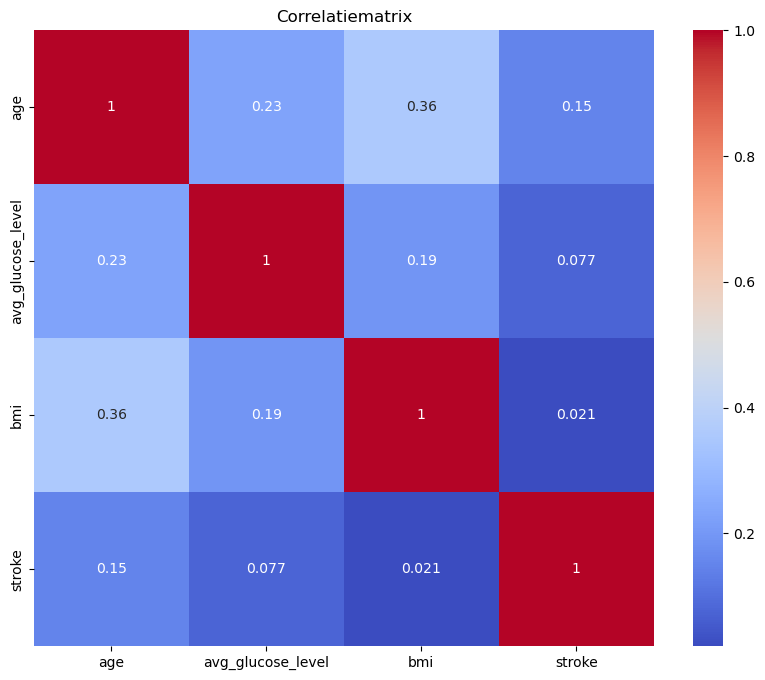

In [7]:
numerieke_kolommen = ['age', 'avg_glucose_level', 'bmi']
numerieke_kolommen.append("stroke")
numeric_only = df[numerieke_kolommen]
corr_matrix = numeric_only.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlatiematrix')
plt.show()


age – stroke = 0.15  lichte positieve correlatie →ouderen hebben meer kans op stroke.

avg_glucose_level – stroke = 0.077 heel zwakke positieve correlatie → iets hogere glucose hangt een beetje samen met stroke.

bmi – stroke = 0.021  vrijwel geen verband.


#### Binaire variabelen

In [8]:
from scipy.stats import pointbiserialr

binaire_kolommen = [
    "hypertension",
    "heart_disease",
    "gender_Female",
    "gender_Other",
    "ever_married_Yes",
    "work_type_Govt_job",
    "work_type_Never_worked",
    "work_type_Self-employed",
    "work_type_children",
    "Residence_type_Urban",
    "smoking_status_formerly smoked",
    "smoking_status_smokes"
]

biserial_results = {}

for kolom in binaire_kolommen:
    corr, p = pointbiserialr(df[kolom].astype(int), df["stroke"])
    biserial_results[kolom] = {'Punt-biseriële correlatie': corr, 'P-waarde': p}

biserial_df = pd.DataFrame.from_dict(biserial_results, orient='index').reset_index()
biserial_df.columns = ['Variabele', 'Punt-biseriële correlatie', 'P-waarde']

display(biserial_df)


,Variabele,Punt-biseriële correlatie,P-waarde
0,hypertension,0.084019,1.274364e-53
1,heart_disease,0.104625,2.729232e-82
2,gender_Female,-0.008727,1.099282e-01
3,gender_Other,-0.001673,7.592566e-01
4,ever_married_Yes,0.066403,4.179271e-34
5,work_type_Govt_job,-0.004439,4.161961e-01
6,work_type_Never_worked,-0.008127,1.365852e-01
7,work_type_Self-employed,0.061883,7.818600e-30
8,work_type_children,-0.050728,1.441488e-20
9,Residence_type_Urban,0.002654,6.268486e-01


heart_disease (0.105) → sterkste verband van de binaire variabelen, mensen met hartziekte hebben meer kans op stroke.

hypertension (0.084) → ook een duidelijke positieve relatie.

ever_married_Yes (0.066) en self-employed (0.062) → lichte positieve verbanden.

work_type_children (-0.051) → negatieve correlatie  kinderen krijgen bijna geen stroke.

smoking_status_formerly smoked (0.034) → heel klein positief verband.

De rest heeft bijna 0 correlatie → nauwelijks effect.

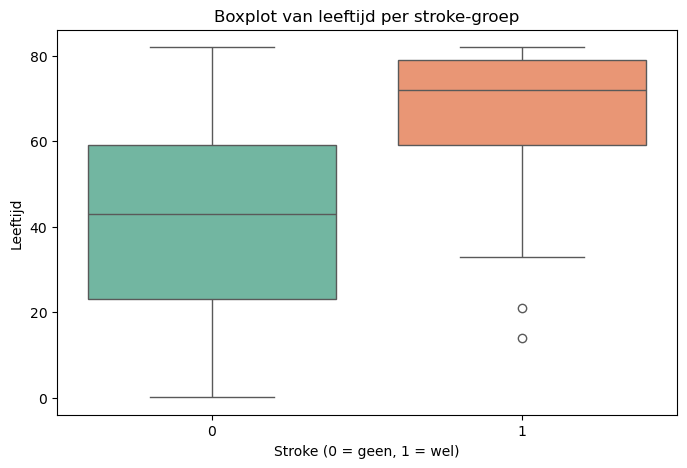

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(
    x="stroke", 
    y="age", 
    hue="stroke", 
    data=df, 
    palette="Set2", 
    legend=False
)


plt.title("Boxplot van leeftijd per stroke-groep")
plt.xlabel("Stroke (0 = geen, 1 = wel)")
plt.ylabel("Leeftijd")
plt.show()


###  boxplot leeftijd per stroke-groep

- Bij 0 (geen stroke) ligt de leeftijd meestal tussen 20 en 60 jaar, met een gemiddelde rond de 40 jaar.  
- Bij  (wel stroke) ligt de leeftijd vooral tussen 60 en 80 jaar, met een gemiddelde rond de 70 jaar.  
- Er zijn enkele uitzonderingen van jonge mensen die ook een stroke hebben gehad.  

 Mensen met een stroke zijn over het algemeen veel ouder dan mensen zonder stroke. Leeftijd is dus een belangrijke factor bij het krijgen van een stroke.


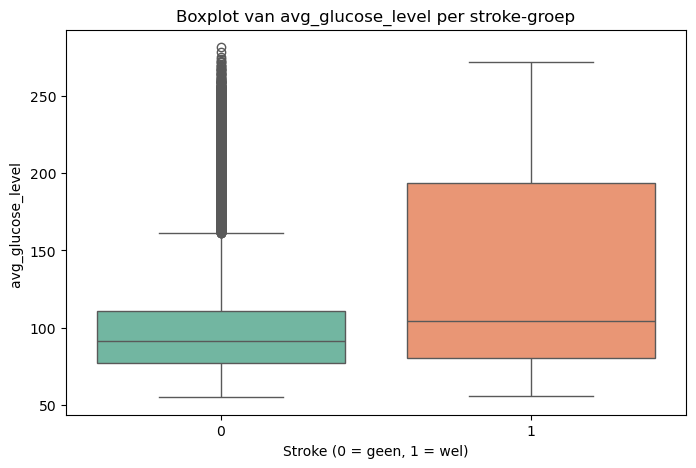

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(
    x="stroke", 
    y="avg_glucose_level", 
    hue="stroke", 
    data=df, 
    palette="Set2", 
    legend=False
)


plt.title("Boxplot van avg_glucose_level per stroke-groep")
plt.xlabel("Stroke (0 = geen, 1 = wel)")
plt.ylabel("avg_glucose_level ")
plt.show()


###  boxplot van avg_glucose_level per stroke-groep

- Bij 0 geen stroke ligt de mediaan van glucose rond de 90, met de meeste waarden tussen 75 en 110.  
- Bij 1 (wel stroke) ligt de mediaan hoger, rond de 105, en de spreiding is duidelijk groter.  
- Er zijn veel outliers met hoge glucosewaarden, vooral bij stroke-patiënten.  

 Mensen met een stroke hebben gemiddeld hogere glucosewaarden dan mensen zonder stroke.  
Glucose lijkt dus een belangrijke factor te zijn bij het voorspellen van stroke.


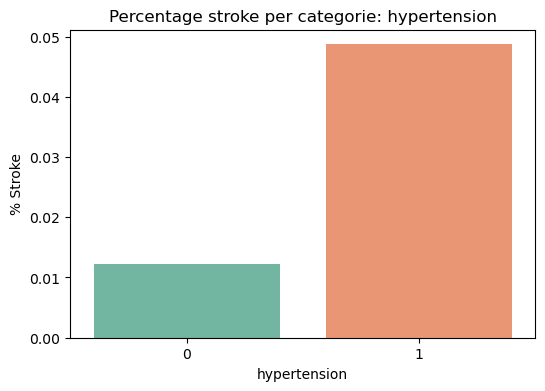

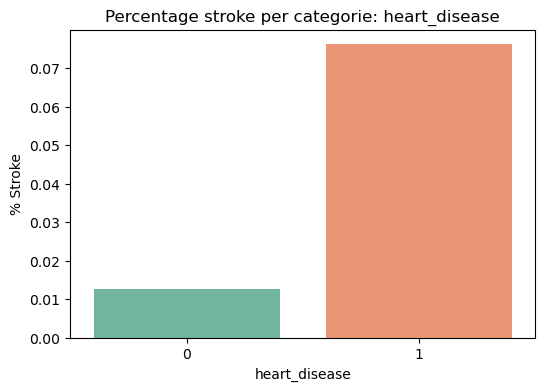

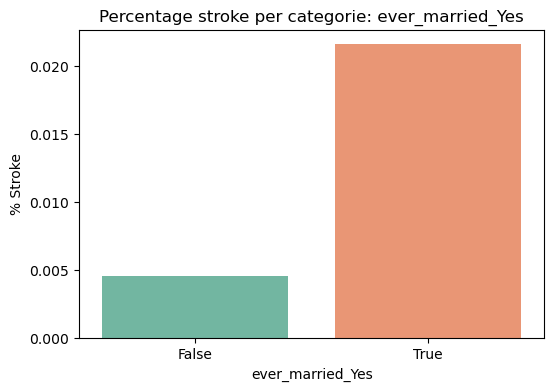

In [11]:
categorische_vars = ["hypertension", "heart_disease", "ever_married_Yes"]

for var in categorische_vars:
    stroke_perc = df.groupby(var)["stroke"].mean().reset_index()
    
    plt.figure(figsize=(6,4))
    sns.barplot(x=var, y="stroke", data=stroke_perc, hue=var, palette="Set2", legend=False)


    plt.title(f"Percentage stroke per categorie: {var}")
    plt.ylabel("% Stroke")
    plt.show()


### Interpretatie barplots: percentage stroke per categorie

1. **Hypertension (hoge bloeddruk)**  
   - Mensen zonder hoge bloeddruk hebben een stroke-percentage van ongeveer **1,2%**.  
   - Mensen mét hoge bloeddruk hebben bijna **5%** kans op een stroke.  
  hoge bloeddruk vergroot de kans op een stroke duidelijk.

2. **Heart disease (hartziekte)**  
   - Zonder hartziekte: ongeveer **1,3%** kans op een stroke.  
   - Met hartziekte: bijna **7,5%** kans.  
   hartziekte is een sterke risicofactor voor een stroke.

3. **Ever married (ooit getrouwd)**  
   - Nooit getrouwd: rond de **0,5%** kans op een stroke.  
   - Wel getrouwd: iets boven de **2%** kans.  
   getrouwde mensen hebben vaker een stroke, waarschijnlijk omdat deze groep gemiddeld ouder is.  

---

**Algemene conclusie:**  
Hoge bloeddruk en hartziekte zijn duidelijke risicofactoren.  
De relatie met getrouwd zijn is minder direct en hangt waarschijnlijk samen met leeftijd.


# Data opschonen

### Multicollineariteit ###

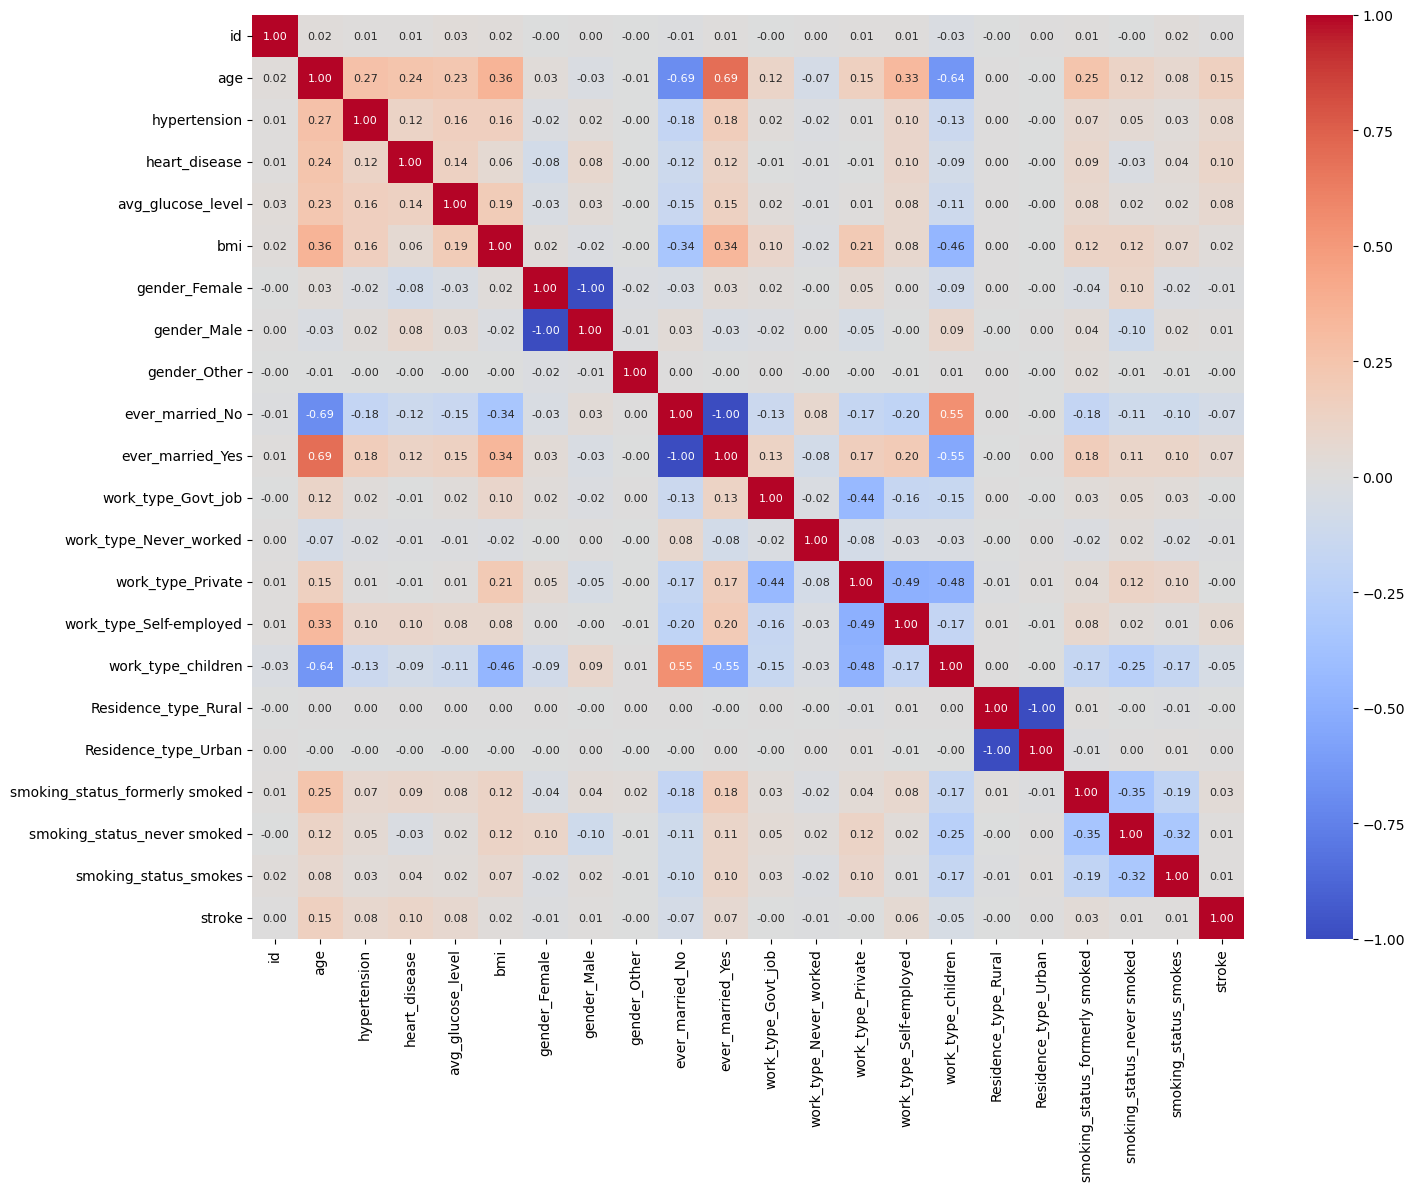

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)  # correlaties tussen numerieke kolommen
plt.figure(figsize=(16,12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, annot_kws={"size":8})
plt.show()



Er is sprake van multicollineariteit. We hebben dit vastgesteld via de correlatiematrix.


#### ever_married_No en ever_married_Yes. #####

Correlatie ≈ -1 (perfect negatief → als No = 1, dan Yes = 0).

#### gender_Female, gender_Male, gender_Other ####
Samenhang heel sterk: als gender_Female = 1, dan gender_Male = 0 en gender_Other = 0.

#### Residence_type_Rural en Residence_type_Urban ####

Perfect negatief gecorreleerd een van de twee is altijd 1.

#### Work_type dummies #####

work_type_Govt_job, work_type_Never_worked, work_type_Private, work_type_Self-employed, work_type_children

Samen optellend altijd 1. Dus ook hier multicollineariteit.

#### Smoking_status dummies #####

smoking_status_formerly smoked, smoking_status_never smoked, smoking_status_smokes

Ook samen optellend bijna altijd 1 → multicollineariteit.
- - -

Dit is een probleem, omdat deze variabelen bijna dezelfde informatie bevatten. In machine learning of regressie kan dit leiden tot instabiele modellen, verkeerde interpretatie van welke variabele belangrijk is en problemen met het schatten van coëfficiënten.

We kunnen terk samenhangende variabelen verwijderen of combineren, om zo overlapping te vermijden en het model eenvoudiger en betrouwbaarder te maken.

In [13]:
cols_to_drop = [
    "gender_Male", 
    "ever_married_No", 
    "Residence_type_Rural", 
    "work_type_Private", 
    "smoking_status_never smoked"
]

df = df.drop(columns=cols_to_drop, errors="ignore")


#### Verwijderen ID  uit de dataset

In [14]:

df.drop(columns=["id"], inplace=True)

 Deze bevat alleen een uniek nummer per persoon en heeft geen voorspellende waarde.

#### Numerieke waarden controleren

In [15]:
display(df.describe())

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,33550.000000,33550.000000,33550.000000,33550.000000,33550.000000,33550.000000
mean,41.815312,0.088137,0.043040,103.587081,28.601216,0.015410
std,22.477423,0.283498,0.202951,42.127396,7.782248,0.123178
min,0.080000,0.000000,0.000000,55.010000,10.100000,0.000000
25%,24.000000,0.000000,0.000000,77.460000,23.300000,0.000000
50%,43.000000,0.000000,0.000000,91.320000,27.700000,0.000000
75%,59.000000,0.000000,0.000000,111.437500,32.800000,0.000000
max,82.000000,1.000000,1.000000,281.590000,97.600000,1.000000


In [16]:
# In de kolom 'age' stonden 376 waarden tussen 0.08 en 0.88 (baby's in maanden).
# Dit was verwarrend omdat de rest van de leeftijden in hele jaren staat.
# Daarom hebben we alle waarden kleiner dan 1 jaar veranderd naar 1 jaar,
# zodat de dataset consistenter en beter bruikbaar is voor de modellen.
df.loc[df["age"] < 1, "age"] = 1


# outliers

In [17]:
numerieke_kolommen = [
    "age", "avg_glucose_level", "bmi"
]


extreme_waarden = {}
for kolom in numerieke_kolommen:
    q1 = df[kolom].quantile(0.25)
    q3 = df[kolom].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[kolom] < lower_bound) | (df[kolom] > upper_bound)]
    extreme_waarden[kolom] = len(outliers)

extreme_waarden_sorted = dict(sorted(extreme_waarden.items(), key=lambda x: x[1], reverse=True))
print(extreme_waarden_sorted)


{'avg_glucose_level': 3641, 'bmi': 769, 'age': 0}


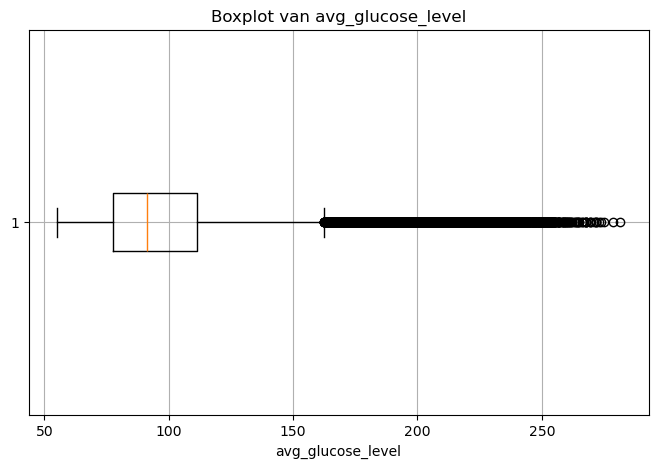

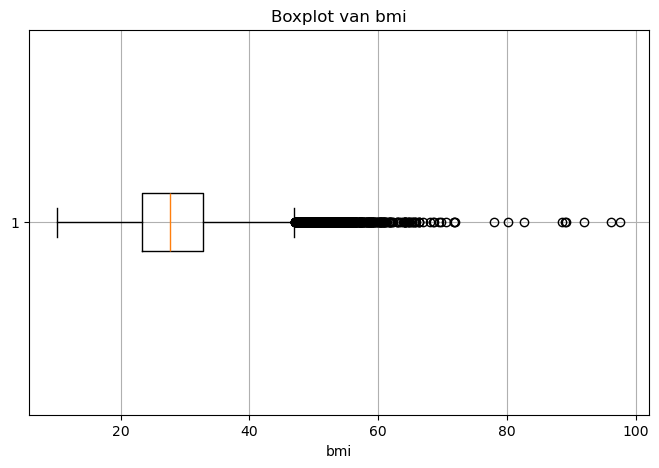

In [18]:
kolommen_met_outliers = [
    'avg_glucose_level', "bmi"
]

#Boxplots tekenen
for kolom in kolommen_met_outliers:
    plt.figure(figsize=(8, 5))
    plt.boxplot(df[kolom].dropna(), vert=False)
    plt.title(f'Boxplot van {kolom}')
    plt.xlabel(kolom)
    plt.grid(True)
    plt.show()



In [19]:
for col in ["bmi", "avg_glucose_level"]:
    lower = df[col].quantile(0.01)   # 1e percentiel
    upper = df[col].quantile(0.99)   # 99e percentiel
    df[col] = df[col].clip(lower, upper)


Bij het controleren van de numerieke kolommen (age, avg_glucose_level, bmi) hebben we gekeken of er outliers aanwezig zijn.

Leeftijd  geen opvallende outliers.

Gemiddeld glucose-niveau  ongeveer 3641 outliers gevonden.

BMI ongeveer 769 outliers gevonden.

Dit zagen we ook duidelijk terug in de boxplots: de meeste waarden vallen binnen een normaal bereik, maar er zijn een aantal extreme hoge waarden (vooral bij glucose en BMI).

Oplossing

Om te voorkomen dat deze extreme waarden onze modellen teveel beinvloeden, hebben we gekozen voor clippen :

Waarden die te laag zijn  vervangen door de ondergrens.

Waarden die te hoog zijn vervangen door de bovengrens.

Op die manier blijft de dataset consistenter en worden de modellen robuuster.

 # Standaardiseren van de data

Standaardiseren betekent dat we de waarden van een kolom omzetten zodat ze een gemiddelde van 0 en een spreiding van 1 hebben. 
    
Dit zorgt ervoor dat alle variabelen op dezelfde schaal staan. Dit is vooral nuttig bij modellen die werken met afstanden,

zoals KNN en SVM. Zonder standaardisatie zou bijvoorbeeld avg_glucose_level met waarden tot 280 zwaarder meetellen dan age maximaal 82.

Voor modellen zoals Decision Trees of Random Forests is standaardisatie niet nodig, maar voor afstandsmodellen wel handig.

Daarom hebben we besloten de kolommen age, bmi en avg_glucose_level te standaardiseren.

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[["age", "avg_glucose_level", "bmi"]] = scaler.fit_transform(df[["age", "avg_glucose_level", "bmi"]])


In [21]:
df

,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Female,gender_Other,ever_married_Yes,work_type_Govt_job,work_type_Never_worked,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_smokes,stroke
0,-0.526100,0,0,-0.955077,0.628893,False,False,False,False,False,False,False,False,False,True,0
1,1.476759,1,0,2.673949,2.577528,True,False,True,False,False,True,False,False,False,False,0
2,-1.193719,0,0,0.759714,-1.266717,False,False,False,False,False,False,False,False,False,False,0
3,0.230536,0,0,-0.924191,-0.047164,False,False,True,False,False,True,False,True,False,False,0
4,0.319552,0,0,2.845620,0.032372,False,False,True,False,False,True,False,False,True,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33545,-1.460767,0,0,0.151085,-1.796958,False,False,False,False,False,False,True,False,False,False,0
33546,0.230536,0,0,-0.356265,0.297493,True,False,True,False,False,False,False,True,False,False,0
33547,-1.727815,0,0,-0.330646,-1.637886,True,False,False,False,False,False,True,False,False,False,0
33548,0.631108,1,0,-0.503993,-0.100188,True,False,True,True,False,False,False,True,False,True,0


## Opdracht 2 - Evaluatie

**2.1 De vorm van Machine Learning**

Bij dit vraagstuk gaat het om *binaire classificatie*, wat een vorm van *supervised learning* is.  
Supervised learning betekent dat we een dataset hebben met features en een bekende target. In dit geval is de doelvariabele "stroke", die twee mogelijke waarden heeft. "0" betekent geen herseninfarct, "1" betekent wel een herseninfarct.  

Omdat de dataset *imbalanced* is, moeten we metrics kiezen die dit goed weergeven. De dataset wordt gezien als imbalanced doordat er relatief veel van een waarde zijn in vergelijking met de ander.

**2.2 Belangrijke metrics**

- Accuracy\
Geeft het percentage correcte voorspellingen, maar kan misleidend zijn bij een imbalanced dataset.\

- Precision\
Hoe vaak is een voorspelde stroke echt een stroke\

- Recall\
Hoeveel van de echte strokes worden correct voorspeld\ 

- F1-score\
Combinatie van precision en recall, wel geschikt bij imbalanced data.  

- ROC-AUC\
  Hoe goed de scheiding is tussen de 2 klasse. 


In [3]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X = df.drop(columns=['stroke'])  
y = df['stroke'] 

#train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

#train/val split
X_train_subset, X_val, y_train_subset, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg.fit(X_train_subset, y_train_subset)
y_pred = log_reg.predict(X_val)

print(classification_report(y_val, y_pred, digits=3))


              precision    recall  f1-score   support

           0      0.995     0.690     0.815      5285
           1      0.039     0.795     0.074        83

    accuracy                          0.692      5368
   macro avg      0.517     0.743     0.444      5368
weighted avg      0.981     0.692     0.804      5368



**2.3 Uitleg metrics en Confusion Matrix**

Accuracy = (TP + TN) / (TP + TN + FP + FN)

Precision = TP / (TP + FP) = van all de positieve voorspellingen, hoeveel zijn er correct.

Recall = TP / (TP + FN) = van alle echte positieven, hoeveel zijn er correct voorspeld.

F1-score = 2 * (Precision * Recall) / (Precision + Recall) = gemiddelde van precision en recall, goed bij imbalanced datasets.

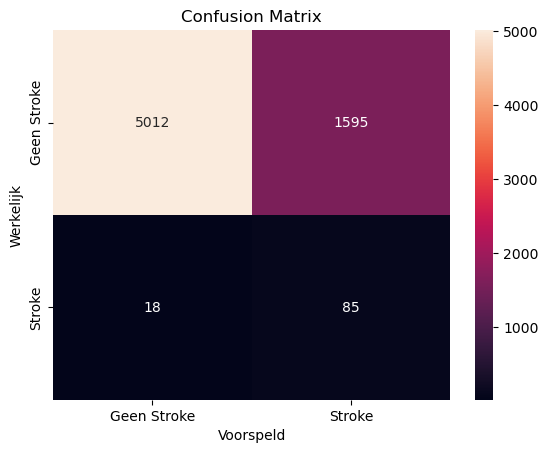

In [23]:
from sklearn.metrics import confusion_matrix

y_pred = log_reg.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Geen Stroke', 'Stroke'], yticklabels=['Geen Stroke', 'Stroke'])
plt.xlabel('Voorspeld')
plt.ylabel('Werkelijk')
plt.title('Confusion Matrix')
plt.show()

**2.4 Waarom de f1-score?**

In deze Kaggle competitie gaat het om het voorspellen van een herseninfarct, wat weinig voorkomt in de dataset. Bij zulke ongelijke verdelingen kan accuracy misleidend zijn, een model dat altijd "geen infarct" voorspelt, kan bijvoorbeeld een hoge accuracy hebben, terwijl het totaal faalt in het detecteren van echte infarcten.

De F1-score combineert precision (hoeveel van de voorspelde infarcten ook echt infarcten zijn) en recall (hoeveel van de echte infarcten correct worden voorspeld) in één metric. Hierdoor geeft de F1-score een betere weging van de prestaties van het model bij de ongerepresenteerde klasse (patiënten met een infarct) en is het daarom de beste metric voor dit classificatieprobleem.

# Opdracht 3 - Modelleren

**3.1 Een imbalanced dataset**

We werken met een binaire classificatie. De doelvariabele is de stroke kolom, waar 0 geen herseninfarct is en 1 wel. De dataset is sterk imbalanced wat betekent dat er zijn veel meer patiënten zonder infarct dan met infarct.

Bij een imbalanced dataset kan een model erg makkelijk heel accuraat zijn door bijna altijd de grootste klasse te voorspellen. De accuracy lijkt dan hoog, maar het model herkent bijna geen gevallen waar het wel een infarct is.

Daarom kiezen we voor de F1-score als belangrijkste evaluatiemetric. Deze maat combineert precision en recall, en geeft zo een beter beeld van de prestaties van het model op de kleine klasse.

**3.2 KNN**

Het KNN model classificeert een datapunt door te kijken naar de k dichtstbijzijnde buren in de trainingsset, met k als een zelfgekozen getal. Het model kijkt dus naar de afstand tussen het het datapunt en de andere datapunten die er omheen zitten. Die afstand kan op meerdere manier worden berekend. De euclidische afstand is een rechte lijn door 2 punten en dan de afstand van die lijn. De manhatten afstand is de som van de absolute verschillen per kenmerk.

KNN gebruikt de afstand tot buren om te classificeren, bijvoorbeeld euclidisch of manhatten. Zonder standaardisatie kunnen features met grotere waarden de afstand extreem erg beïnvloeden, waardoor verkeerde buren gekozen worden. Door standaardisatie krijgen alle features gelijke invloed door alles naar dezelfde schaal te brengen.

Bij KNN werkt regularisatie via de hyperparameter k. Een klein k kan overfitting veroorzaken, een groter k maakt het model stabieler en beter generaliseerbaar. Ook de keuze van afstandsmetrieken beïnvloedt de gevoeligheid voor extreme waarden.

In [24]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.neighbors import KNeighborsClassifier
from imblearn.under_sampling import RandomUnderSampler

X = df.drop(columns=['stroke'])
y = df['stroke']

#train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

#rus (undersampling) toepassen
rus = RandomUnderSampler(random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

#normaliseren
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier()

param_grid = {
    'n_neighbors': [15, 17, 19, 21, 23],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1)

grid_search.fit(X_train_scaled, y_train_res)

# Resultaten
print("Beste parameters KNN:", grid_search.best_params_)
print("Beste F1-score van een fold:", grid_search.best_score_)

best_knn = grid_search.best_estimator_
y_test_pred = best_knn.predict(X_test_scaled)
print("Test F1-score:", f1_score(y_test, y_test_pred))

Beste parameters KNN: {'metric': 'manhattan', 'n_neighbors': 19, 'weights': 'uniform'}
Beste F1-score van een fold: 0.7744706100111098
Test F1-score: 0.08591625883632407


**De 2 gekozen technieken om class imbalance tegen te gaan;**

Undersampling (RUS): Dit verwijdert willekeurig voorbeelden van de meerderheidsklasse, zodat de frequentie van elke klasse meer gelijk is. Zo wordt het model niet te veel beïnvloed door de meerderheid.

class_weight='balanced': Het model weegt automatisch de klasse om de minderheidsklasse zwaarder mee te laten tellen. Hierdoor let het model beter op de kleine klasse bij het maken van voorspellingen.

**3.3 Logistic Regression**

*Hoe het werkt:*\
Logistic Regression voorspelt de kans dat een datapunt bij een bepaalde klasse hoort. Het model berekent eerst een lineare combinatie van alle kenmerken met deze functie: *y = W1​X1 ​+ W2X2 ​+ ... + Wn​Xn ​+ b*. Vervolgens gebruikt het model een sigmoidfunctie om een waarde tussen 1 en 0 te krijgen. Als die waarde dan boven 0.5 is word klasse 1 voorspelt, ander klasse 0.

*Loss functie (log loss):*\
Dit is de formule; L = -(1/m) * sum( y_i * log(p_i) + (1 - y_i) * log(1 - p_i) ).\
m = aantal voorbeelden in je dataset\
y_i = de echte waarde voor voorbeeld i (0 of 1)\
p_i = de voorspelde kans dat voorbeeld i de klasse 1 heeft\

Als y_i = 1 en p_i dichtbij 1 is, wordt de loss klein.\
Als y_i = 0 en p_i dichtbij 0 is, wordt de loss klein.\
Als het model het fout heeft, wordt de loss groot.\
De loss wordt dus kleiner als het model beter voorspelt en groter als het model slecht voorspelt.

*Gradient descent:*\
Met gradient descent pas je de waardes van de features aan om de loss te minimaliseren. Dit is de formule; Xnew = Xold - α( dy / dx ). Xold is de x coordinaat van het initiele punt, alpha is de learning rate en dy/dx is de hellingsgraad/gradient.Een voorbeeld situatie is; x=0.5, α=0.1 en dx/dy = 2 -> 0.5 - 0.1 * 2 -> 0.3 -> de nieuwe x coordinaat is dan 0.3

*Regularisatie:*\
Met logistic regression zijn er 2 belangrijke vormen van regularisatie L1(lasso) en L2(ridge). Ze kunnen beide de invloed van elk kenmerk aanpassen. Bij L2 kunnen de features verlaagd worden, hier word deze formule voor gebruikt; L_total = L + lambda * (w1^2 + w2^2 + ... + wn^2)​. Bij L1 kunnen de features zelf verwijderd worden, dan worden ze op 0 gezet, dit is de formule; L_total = L + lambda * (|w1| + |w2| + ... + |wn|).\
L = originele loss, w1 w2 etc zijn de gewichten van het model en lambda is de sterkte van de regularisatie.

*Regularisatie t.o.v. overfitting*\
Zonder regularisatie kan het model te veel leren van trainingsdata en zal het leiden tot een overfit model. Met regularisatie worden gewichten verlaagd en sommige misschien zelfs helemaal op 0 gezet, waardoor het model beter generaliseert naar nieuwe data en dus betere voorspellingen maakt.

In [25]:
from imblearn.over_sampling import SMOTE

#1e techniek tegen imbalance: smote (oversampling van de minderheidsklasse)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

#2e techniek tegen imbalance: class_weight='balanced'
log_reg = LogisticRegression(
    max_iter=5000,
    class_weight='balanced',
    random_state=42)


param_grid = {
    'C': [0.01, 0.05, 0.08, 0.1, 0.12, 0.2, 0.5],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']}


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1)

grid_search.fit(X_train_res, y_train_res)

#resultaten
print("Beste parameters:", grid_search.best_params_)
print("Beste F1-score (CV):", grid_search.best_score_)

best_logreg = grid_search.best_estimator_
y_test_pred = best_logreg.predict(X_test)
print("Test F1-score:", f1_score(y_test, y_test_pred))

Beste parameters: {'C': 0.05, 'penalty': 'l2', 'solver': 'liblinear'}
Beste F1-score (CV): 0.8078199862488178
Test F1-score: 0.08841634023503078


**3.4 SVM**

*Hoe het werkt*:\
Een Support Vector Machine probeert het beste scheidingsvlak te vinden dat de klassen in de dataset zo goed mogelijk van elkaar scheidt. Het idee is dat dit vlak niet alleen de data scheidt, maar dat de marge tot de dichtstbijzijnde datapunten van beide klassen (oftowel de support vectors) zo groot mogelijk is. Alle support vectors tellen mee bij het model, maar de rest van de datapunten hebben helemaal geen invloed erop.

*Wiskunde achter het model:*\
Het scheidingsvlak is linear te beschrijven voor de ingekorte dataset met 2 features op deze manier: w1 * age + w2 * bmi + b = 0. w1 en w2 zijn de gewichten van de features en b is de bias term. Dataputen die dichtbij liggen zijn dus de support vectors en bepalen dus ook de marge van het model, SVM probeerd deze marge dus maximaal te maken. Voor het voorbeeld nemen we aan dat het SVM model deze gewichten en bias heeft: w_age = 1, w_bmi = 1, b = -0.5. De beslissingsfunctie is dan: f(x) = w_age * age + w_bmi * bmi + b. Per regel uit de dataset kunnen we dan de voorspelling berekenen, de regels staan in de onderstaande code-cel geprint.

f(x) = 1 * (-0.5261) + 1 * 0.6289 - 0.5 = -0.3972  > klasse 0 \
f(x) = 1 * 1.6993 + 1 * 0.4168 - 0.5 = 1.6161  > klasse 1 \
Omdat f(x) > 0 word dit punt correct geclassificeerd als klasse 1. Punten met f(x) < 0 worden als klasse 0 voorspeld.



*Kernel en Kernel Trick:*\
Niet alle data is lineair scheidbaar. Een kernel is een functie die de data naar een hogere dimensie afbeeld, waar een lineare scheiding wel mogelijk kan zijn. Voorbeelden hiervan zijn met een lineare kernel of met RBF. De kernel trick doet dit maar efficiënter, zonder de data echt naar een hogere dimensie te transformeren berekent de kernel direct wat de overeenkomst tussen datapunten in een hogere dimensie is. Hiermee kan een SVM model dus niet lineare grenzen leren zonder extreem zware code uit te voeren.


In [26]:
display(df[['age', 'bmi', 'stroke']].head(1))
df[df['stroke'] == 1][['bmi', 'age', 'stroke']].head(1)

,age,bmi,stroke
0,-0.5261,0.628893,0


,bmi,age,stroke
28,0.416797,1.699299,1


*Loss functie van SVM:*\
Bij SVM kan zowel L2 als Hinge gebruikt worden als de loss functie, Hinge is de meest gebruikte. De hinge loss functie van een datapunt is dan:\
L_i = max(0, 1 - y_i * (w * x_i + b)) \
x_i = input vectors (bv zoals hierboven: [age, bmi])
y_i = klasse van het punt, -1 of 1 (0 word -1) \
w = gewichten van het model \
b = bias term \
Als het punt correct wordt geclassificeerd en ver genoeg van de scheidingslijn ligt is de loss 0. \
Als het punt fout geclassificeerd is of te dicht bij de marge ligt, wordt de loss positief.

*Regularisatie:*\
Bij dit model zijn 2 vormen van regularisatie van toepassing, L1 en L2. De loss functie voor L2 regularisatie voor dit model is:\
Loss = (1/n) * sum_i max(0, 1 - y_i * (w * x_i + b)) + lambda * sum_j w_j^2 \
n = aantal trainingspunten \
y_i = klasse van punt i \
x_i = input vector van punt i \
w = vector van gewichten \
b = bias term \
lambda = regularisatieparameter (hoe groter, hoe sterker de beperking op w) \
w_j^2 = kwadraat van elk gewicht \
L2-regularisatie beperkt de grootte van de gewichten. \
Zo wordt de scheidingslijn niet te complex en blijft het model beter generaliseren naar nieuwe data.

De loss functie voor L1 regularisatie voor dit model is:\
Loss = (1/n) * sum_i max(0, 1 - y_i * (w*x_i + b)) + lambda * sum_j |w_j| \
L1 beperkt ook de grootte van de gewichten, maar kan sommige gewichten exact op 0 zetten. \
Dit kan helpen om irrelevante features uit te schakelen (feature selectie).

In [ ]:
from sklearn.svm import SVC

#1e techniek tegen imbalance: smote (oversampling van de minderheidsklasse)
smote = SMOTE(random_state=1)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

#2e techniek tegen imbalance: class_weight='balanced'
svm = SVC(class_weight='balanced')

param_grid = {
    'C': [9,10, 11, 12],  
    'kernel': ['linear', 'rbf'],  
    'gamma': ['scale', 'auto']}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1)


grid_search.fit(X_train_scaled, y_train_res)


print("Beste parameters SVM:", grid_search.best_params_)
print("Beste F1-score (CV):", grid_search.best_score_)

best_svm = grid_search.best_estimator_
y_test_pred = best_svm.predict(X_test_scaled)
print("Test F1-score:", f1_score(y_test, y_test_pred))

Beste parameters SVM: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Beste F1-score (CV): 0.8868312545519949
Test F1-score: 0.06828528072837632


**3.5 Decision Tree**

*Hoe werkt dit model:*\
Een decision tree of in dit geval een classification tree werkt door op basis van een reeks if-statements data te splitsen om uiteindelijk de meest pure splitsingen te maken. Het traint zichzelf door zelf if statements te maken en te kijken welke resulteren in de beste/meeste pure splitsingen. Bij elke node word er gekeken naar welk kenmerk met welke waarde zorgt voor de meest pure split. Dit gebeurd op basis van de splitscriteria, bijvoorbeeld de gini-index en de entropy. Bij de gini-index word er gekeken naar hoe niet-puur een bepaalde split is. Een lagere gini betekent een meer pure node en wanneer gini word gebruikt om mee te splitsen gebruikt het model het kenmerk met de bijhorende waarde die voor de laagste gini zorgt. Entropy kijkt naar de information gain na een split. Information gain is de kennis die je opdoet over de gesplitste data de bereking hierbij is: information gain = entropy(ouder_node) – gewogen som van entropy(kinderen_nodes). En voorbeeld is: neem een dataset met 5 rijen, 2 zijn klasse 2 en 3 zijn klasse 1. De gini index van deze dataset is dan 0.971 (bereking is nu even irrelevant). Vervolgens kiest het model een waarde van een kenmerk om op te splitsen. Na deze split zouden de 2 rijen met klasse 2 in de linker node en de 3 rijen met klasse 1 in de rechter node. Vervolgens wordt hier per node entropy van berekent en gebeurd de berekening van information gain: 0.971 - (2/5 * 0, 3/5 * 0) = 0.971 info gain. (de 0 in de formule is de entropy van de linker en rechter node respectivelijk)

In [45]:
from sklearn.tree import DecisionTreeClassifier

#Ik gebruik hier weer de gegevens waarop SMOTE is toegepast en class_weight='balanced' gebruikt als balance technieken.

dt = DecisionTreeClassifier(class_weight='balanced', random_state=1)


param_grid = {
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 3, 4, 5],
    'min_samples_leaf': [1, 2, 3],
    'class_weight': ['balanced']}


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)


grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1)

grid_search.fit(X_train_res, y_train_res)


print("Beste parameters Decision Tree:", grid_search.best_params_)
print("Beste F1-score (CV):", grid_search.best_score_)

best_dt = grid_search.best_estimator_
y_test_pred = best_dt.predict(X_test)
print("Test F1-score:", f1_score(y_test, y_test_pred))

Beste parameters Decision Tree: {'class_weight': 'balanced', 'max_depth': 6, 'min_samples_leaf': 3, 'min_samples_split': 2}
Beste F1-score (CV): 0.8342525012467782
Test F1-score: 0.09155383623468731


**Pruning:**\
Pruning is het beperken van een decision tree zodat die niet oneindig veel nodes maakt zodat het model niet overfit op de trainingsdata. Zonder pruning wordt het model een perfecte fit op de trainingsdata en kan het niet generaliseren naar nieuwe data. Er zijn 2 vormen van pruning; pre-pruning en post-pruning. Pre-pruning word gedaan voordat het model getraind is en voorkomt hoe ver een decision tree kan groeien, in dit geval wordt dat gedaan door de meegegeven hyperparameters van max_depth, min_samples_leaf en min_samples_split. Post-pruning is eerst de boom zichzelf laten trainen zonder het te beperken en nadat het model volledig getraind is een stuk van de tree 'af te snoeien'. Bij ons model wordt dit niet gedaan.

De relatie tussen pruning en over/underfitting is:\
Post pruning verkleint de kans op overfitting door takken van de boom die weinig bijdragen aan de voorspelling te verwijderen. Pre pruning voorkomt de kans op overfitting doordat je de boom niet diep genoeg laat groeien om overfitting te kunnen laten gebeuren.
Het model wordt hierdoor eenvoudiger en generaliseert beter naar nieuwe data. Zonder pruning kan de boom te diep worden en de training data te nauwkeurig volgen. Te veel pruning kan echter leiden tot underfitting, omdat belangrijke patronen mogelijk worden weggeknipt of omdat er nooit belangrijke patronen kunnen ontstaan.


**3.6 Ensembles**

*Random Forest:*\
Random forest is een ensemble methode die een decision tree als standaard estimator gebruikt. Bij RF wordt elk model getraind op een bootstrap sample van de originele dataset die even groot is als de trainingsset. RF zorgt ook voor meer randomising dan bagging, omdat wanneer elke boom getraind wordt maar een aantal features worden meegenomen, nooit allemaal. Alle decision trees worden tegelijkertijd getraind waardoor het dus een parallelle werking heeft en dus relatief weinig tijd nodig heeft om te trainen.

*GBDT:*\
Gradient boosting is een ensemble methode die een groot aandeel zwakke modellen combineerd om een sterker model te maken. Het idee achter gradient boosting is dat elk model doorgaat met het vorige modelen en zich focussed op de fouten van het vorige model en met gradient descent op de loss functie het vorige model corrigeerd. Gradient boosting decision trees is een vorm van gradient boosting waarbij alle (zwakke) modellen decision trees zijn. Omdat elk model zich richt op de fouten van het vorige model kunnen niet alle modellen tegelijkertijd getraind worden, maar gebeurd dat dus sequentieel, dit zorgt ervoor dat de trainingstijd langer is dan parallelle modellen.

*XGB:*\
XGboost staat voor Extreme gradient boosting en is een verbeterde versie van normal gradient boosting. Net als GB gebruikt het decision trees als zwakke modellen maar in tegenstelling tot GB wordt er wel regularisatie toegepast en heeft het model een parallelle werking waardoor het sneller is dan nomale GB.


In [3]:
pip install xgboost

  Obtaining dependency information for xgboost from https://files.pythonhosted.org/packages/00/5a/f43bad68b31269a72bdd66102732ea4473e98f421ee9f71379e35dcb56f5/xgboost-3.0.5-py3-none-win_amd64.whl.metadata
   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/56.8 MB 682.7 kB/s eta 0:01:24
   ---------------------------------------- 0.1/56.8 MB 1.5 MB/s eta 0:00:39
    --------------------------------------- 0.9/56.8 MB 8.4 MB/s eta 0:00:07
   -- ------------------------------------- 3.6/56.8 MB 22.9 MB/s eta 0:00:03
   -- ------------------------------------- 3.6/56.8 MB 17.7 MB/s eta 0:00:04
   --- ------------------------------------ 5.0/56.8 MB 20.0 MB/s eta 0:00:03
   ----- ---------------------------------- 7.3/56.8 MB 24.5 MB/s eta 0:00:03
   ------- -------------------------------- 10.3/56.8 MB 36.3 MB/s eta 0:00:02
   --------- ------------------------------ 13.1/56.8 MB 43.7 MB/s eta 0:00:01
   ---------- --------

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier

#bij deze modellen word gebruik gemaakt van random under sampling (RUS) en class_weight='balanced'

rus = RandomUnderSampler(random_state=21)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#random forest
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200, 400, 800],
    'max_depth': [5, 10, 20, 30, 40],
    'min_samples_split': [2, 3, 4, 5],
    'min_samples_leaf': [1, 2, 3, 4]}

grid_rf = GridSearchCV(rf, param_grid_rf, scoring='f1', cv=cv, n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train_res)

print("Beste parameters Random Forest:", grid_rf.best_params_)
print("Beste F1-score (CV):", grid_rf.best_score_)

rf_best = grid_rf.best_estimator_
y_pred_rf = rf_best.predict(X_test_scaled)
print("Test F1-score RF:", f1_score(y_test, y_pred_rf))

Beste parameters Random Forest: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 400}
Beste F1-score (CV): 0.7936143331907662
Test F1-score RF: 0.0877005347593583


In [ ]:
#gradient booosting decision trees
gbdt = GradientBoostingClassifier(random_state=100)

param_grid_gbdt = {
    'n_estimators': [400, 800],
    'learning_rate': [0.025, 0.05, 0.075, 0.1, 0.2],
    'max_depth': [3, 5, 7]}

grid_gbdt = GridSearchCV(gbdt, param_grid_gbdt, scoring='f1', cv=cv, n_jobs=-1)
grid_gbdt.fit(X_train_scaled, y_train_res)

print("\nBeste parameters GBDT:", grid_gbdt.best_params_)
print("Beste F1-score (CV):", grid_gbdt.best_score_)

gbdt_best = grid_gbdt.best_estimator_
y_pred_gbdt = gbdt_best.predict(X_test_scaled)
print("Test F1-score GBDT:", f1_score(y_test, y_pred_gbdt))


Beste parameters GBDT: {'learning_rate': 0.025, 'max_depth': 3, 'n_estimators': 400}
Beste F1-score (CV): 0.7791649953381222
Test F1-score GBDT: 0.09120521172638436


In [ ]:
#extreme gradient boosting
xgb = XGBClassifier(scale_pos_weight=1, random_state=1, eval_metric='logloss')

param_grid_xgb = {
    'n_estimators': [200, 400, 600],
    'learning_rate': [0.05, 0.075, 0.1, 0,15, 0.2],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.6, 0.8, 1.0]}

grid_xgb = GridSearchCV(xgb, param_grid_xgb, scoring='f1', cv=cv, n_jobs=-1)
grid_xgb.fit(X_train_scaled, y_train_res)

print("\nBeste parameters XGBoost:", grid_xgb.best_params_)
print("Beste F1-score (CV):", grid_xgb.best_score_)

xgb_best = grid_xgb.best_estimator_
y_pred_xgb = xgb_best.predict(X_test_scaled)
print("Test F1-score XGB:", f1_score(y_test, y_pred_xgb))


Beste parameters XGBoost: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Beste F1-score (CV): 0.7766159821854526
Test F1-score XGB: 0.09304997128087306


**3.7 Eigen Ensemble**\

*Hoe wekt een ensemble en welke manier van voting:*\
Een ensemble combineerd een groot aantal zwakke modellen om er 1 sterk model van te maken. Een model wordt getraind maar het volgende model richt zich dan meer op de fouten van het vorige model, en zo doet elk model dat. De gedachte hierachter is dat uiteindelijk de fouten uit het model eruit getimmerd worden.\
Bij classificatie zijn er 2 opties van voting, soft en hard. Bij hard voting wordt er gekozen voor de voorspelling met de meeste stemmen en bij soft voting wordt er gekozen voor de voorspelling met de hoogste gemiddelde voorspelde kans. In dit geval is soft voting de beste keuze, omdat het rekening houdt met de voorspelde waarschijnlijkheden. Zo krijgt een zeldzame klasse meer kans om correct voorspeld te worden. Dit is dus de beste keuze wanneer de dataset erg imbalanced is zoals in dit geval.

*De gekozen modellen:*\
Omdat er in een extreme imbalance zit in de dataset en het gaat om binaire classificatie is het handig om modellen te kiezen die goed kunnen omgaan met class imbalance, niet snel overfitten en zowel eventuele lineare als niet lineare relaties kan vinden in de dataset. Daarom hebben we gekozen voor de volgende 3 modellen:

Random forest:\
Random Forest bestaat uit meerdere decision trees die met bagging op subsets van de data worden getraind. Hierdoor is het model stabiel en minder gevoelig voor overfitting. Het heeft ook de ingebouwde parameter class_weight='balanced', waardoor het rekening houdt met de ongelijke verdeling in de dataset. RF is bovendien goed in het herkennen van patronen tussen variabelen.

XGBoost:\
XGBoost is zelf geen model maar een boosting-algoritme dat meerdere zwakke decision trees combineert tot een sterk model. Het traint sequentieel waarbij elke nieuwe boom zich meer focussed op de fouten van de vorige. Dit zorgt voor hogere accuracy, ook bij een imbalanced dataset. XGBoost heeft ook de parameter scale_pos_weight waarmee de positieve klasse zwaarder meegewogen kan worden(in plaats van class_weight=balanced zoals bij andere modellen). Ook bevat het ingebouwde L1 en L2 regularisatie, wat de kans op overfitting verminderd.

Logistic regression:\
Logistic Regression is een simpel linear model. Dit model heeft wel de class_weight='balanced' parameter, wat helpt bij een ongelijk verdeelde dataset. Logistic regression voegt als enige van de 3 een linear deel toe aan het model wat voor meer stabiliteit kan zorgen in de voorspellingen.


In [13]:
from sklearn.ensemble import VotingClassifier
#we hebben wederom gekozen voor RUS en class_weight=balanced

rf = RandomForestClassifier(class_weight='balanced', random_state=1)
#xgb heeft geen class_weight parameter, maar een scale_pos_weight parameter, stel dat er 1000 x klasse 0 datapunten zijn en 50 x klasse 1 datapunten zijn
#dan wordt het 1000/50 = 20, wat betekent dat fouten op 1 20x zo zwaar meetellen als fouten op 0.
xgb = XGBClassifier(scale_pos_weight=(y_train_res==0).sum()/(y_train_res==1).sum(), use_label_encoder=False, eval_metric='logloss', random_state=1)
lr = LogisticRegression(class_weight='balanced', solver='liblinear', random_state=1)

ensemble = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb), ('lr', lr)],
    voting='soft')

# Hyperparameter tuning (voorbeeld)
param_grid = {
    'rf__n_estimators': [200, 400],
    'rf__max_depth': [None, 10, 20],
    'xgb__learning_rate': [0.01, 0.05, 0.075, 0.1],
    'xgb__max_depth': [3, 5, 8],
    'lr__C': [1, 5, 7.5, 10]}

grid = GridSearchCV(ensemble, param_grid, scoring='f1', cv=3, n_jobs=-1)
grid.fit(X_train_res, y_train_res)

print("Beste parameters:", grid.best_params_)

y_pred = grid.predict(X_test)
print("Test F1-score:", f1_score(y_test, y_pred))

c:\Users\toms2\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:43:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Beste parameters: {'lr__C': 1, 'rf__max_depth': None, 'rf__n_estimators': 400, 'xgb__learning_rate': 0.05, 'xgb__max_depth': 5}
Test F1-score: 0.09491903964265773
